# KAJIAN ANALITIK: CREDIT RISK SCORING & DEFAULT PREDICTION
**Pemenuhan Portofolio Sertifikasi Data Scientist (SKKNI)**

- **Dokumen**: Notebook 01 - Business Understanding & Exploratory Data Analysis (EDA)
- **Dataset**: Statlog (German Credit Data) - UCI Machine Learning Repository [https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data]

---

**Pemenuhan Portofolio Sertifikasi Data Scientist (SKKNI)**

**Dokumen**: Notebook 01 - Business Understanding & Exploratory Data Analysis (EDA)
**Unit Kompetensi Tercakup**:
* J.62DMI00.001.1 (Menentukan Objektif Bisnis)
* J.62DMI00.002.1 (Menentukan Tujuan Teknis Data Science)
* J.62DMI00.007.1 (Menentukan Objek Data)
* J.62DMI00.005.1 (Menelaah Data)

---

## 1. Pemahaman Bisnis (Business Understanding)
**[SKKNI: J.62DMI00.001.1 - Menentukan Objektif Bisnis]**

### 1.1 Rasionalisasi Pemilihan Objektif Bisnis
**Alasan Utama (Why):** Industri perbankan beroperasi di atas manajemen risiko. Masalah utama yang dihadapi bukan sekadar tingkat kegagalan bayar, melainkan **Asymmetric Loss Function** (Fungsi Kerugian Asimetris). Secara finansial, kerugian yang diderita bank akibat meloloskan satu nasabah berisiko tinggi (gagal bayar) jauh lebih masif daripada kehilangan potensi keuntungan dari menolak satu nasabah baik. Penyaluran kredit massal tanpa personalisasi risiko memicu pembengkakan pencadangan kerugian (*Allowance for Impairment Losses*) yang menggerus laba bersih perusahaan.

**Urgensi Tindakan & Dampak Finansial:**
Oleh karena itu, objektif bisnis ini dipilih untuk mentransformasi sistem penilaian kredit dari pendekatan subjektif menjadi pendekatan *data-driven predictive scoring*. Dengan memetakan probabilitas risiko secara granular, manajemen dapat menurunkan rasio *Non-Performing Loan* (NPL), yang secara langsung akan membebaskan modal cadangan bank untuk diputar kembali menjadi aset produktif.

---

## 2. Tujuan Teknis Data Science
**[SKKNI: J.62DMI00.002.1 - Menentukan Tujuan Teknis Data Science]**

### 2.1 Justifikasi Teknis Pemilihan Target dan Metrik Evaluasi
* **Task Data Science:** Mengembangkan model Klasifikasi Biner (*Supervised Learning*).
* **Target (Label):** `0 = Good Credit` (Lancar) dan `1 = Bad Credit` (Gagal Bayar/Default).

**Alasan Utama Evaluasi Metrik (Why Recall & ROC-AUC?):**
Mengapa optimasi difokuskan pada metrik **Recall** kelas minoritas dan **ROC-AUC**, bukan sekadar *Accuracy*? Pada dataset riil, akurasi adalah metrik yang manipulatif ketika menghadapi ketidakseimbangan kelas (*class imbalance*). Secara teknis dan bisnis, kita harus meminimalkan nilai *False Negatives* (FN)—yaitu kondisi di mana nasabah sebenarnya berisiko tinggi tetapi diprediksi aman oleh model. Optimasi *Recall* Kelas 1 akan memastikan sebanyak mungkin calon nasabah macet dapat diisolasi dan ditolak sejak awal proses pengajuan (*origination*).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Konfigurasi estetika visual korporat
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

import warnings
warnings.filterwarnings('ignore')

print("Environment setup selesai.")

Environment setup selesai.


## 3. Penentuan Objek Data
**[SKKNI: J.62DMI00.007.1 - Menentukan Objek Data]**

Dataset asli berformat matriks dengan pemisah spasi tanpa *header* kolom. Berdasarkan artefak kamus data (`data_dictionary.txt`) dan kueri SQL arsitektur yang telah dirancang sebelumnya, kita mendefinisikan 20 atribut prediktor dan 1 target variabel.

### 3.1 Landasan Ontologis Pemilihan Atribut Data

**Alasan Utama (Why):**
Mengapa kita mengekstraksi 20 atribut spesifik ini (seperti `checking_account_status`, `duration_months`, `credit_history`, `credit_amount`, `age_years`) dari Data Warehouse perbankan? Pemilihan objek data ini didasarkan pada literatur manajemen risiko kredit tradisional (Prinsip 5C: *Character, Capacity, Capital, Collateral, Condition*).
* Atribut Finansial (`checking_account_status`, `savings_account_status`) mencerminkan *Capital* dan *Capacity* (likuiditas berjalan).
* Atribut Perilaku (`credit_history`) mencerminkan *Character* (rekam jejak kepatuhan di masa lalu).
* Atribut Struktural Pinjaman (`duration_months`, `credit_amount`) mencerminkan eksposur risiko yang diambil.

**Urgensi Tindakan:**
Tanpa menyatukan dimensi perilaku keuangan dan demografi ini ke dalam satu *flat-table* entitas unik nasabah, model klasifikasi tidak akan memiliki prediktor yang kaya (*features richness*) untuk menangkap sinyal-sinyal halus dari potensi kegagalan bayar di masa depan.

In [5]:
# Mendefinisikan nama kolom berdasarkan Data Dictionary standar industri
columns = [
    'checking_account_status', 'duration_months', 'credit_history', 'purpose', 
    'credit_amount', 'savings_account_status', 'employment_duration', 
    'installment_rate', 'personal_status_sex', 'other_debtors_guarantors', 
    'present_residence_since', 'property', 'age_years', 'other_installment_plans', 
    'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 
    'target_risk'
]

# Mencoba dua kemungkinan path langsung ke file 'german.data'
path_1 = '../data/raw/german.data'  # Jika Jupyter dijalankan dari dalam folder /notebooks
path_2 = 'data/raw/german.data'     # Jika Jupyter dijalankan dari root folder proyek

if os.path.exists(path_1):
    DATA_PATH = path_1
elif os.path.exists(path_2):
    DATA_PATH = path_2
else:
    DATA_PATH = None

if DATA_PATH:
    # Membaca data dengan pemisah spasi (space-separated)
    df = pd.read_csv(DATA_PATH, sep=' ', header=None, names=columns)
    print(f"Berhasil! Data dimuat dari: {DATA_PATH}")
    print(f"Dimensi matriks: {df.shape}")
    
    # Rekonstruksi Label Target untuk Standarisasi Machine Learning
    # 0 = Good (Negative Class), 1 = Bad (Positive Class)
    df['target_risk'] = df['target_risk'].map({1: 0, 2: 1})
    
    display(df.head())
else:
    print("ERROR: Fail german.data tidak ditemukan!")
    print("Pastikan Jupyter Notebook dijalankan dari folder 'notebooks' atau root proyek.")

Berhasil! Data dimuat dari: ../data/raw/german.data
Dimensi matriks: (1000, 21)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_status,employment_duration,installment_rate,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


## 4. Penelaahan Data (Exploratory Data Analysis / EDA)
**[SKKNI: J.62DMI00.005.1 - Menelaah Data]**

Eksplorasi data difokuskan pada pemahaman distribusi statistik, identifikasi kardinalitas anomali, dan deteksi korelasi awal antara prediktor dan target (Risiko Gagal Bayar).

### 4.1 Justifikasi Pelaksanaan Exploratory Data Analysis (EDA)

**Alasan Utama (Why):**
Mengapa tahapan penelaahan data statistik deskriptif dan analisis bivariat wajib dilakukan sebelum pemodelan? Hukum dasar Machine Learning adalah *Garbage In, Garbage Out*. Kita tidak bisa menyuntikkan data mentah langsung ke dalam algoritma tanpa memahami karakteristik dasarnya. 

**Urgensi Tindakan:**
Berdasarkan visualisasi dan statistik deskriptif yang dijalankan, ditemukan dua temuan krusial yang mendikte arsitektur rekayasa fitur selanjutnya:
1. **Adanya Polarisasi Skala:** Sumbu fitur `credit_amount` memiliki rentang nilai ribuan, sementara fitur `age_years` atau `duration_months` hanya puluhan. Jika langsung dimasukkan ke model linier seperti *Logistic Regression*, bobot model akan terdistorsi secara tidak adil oleh fitur ber-magnitudo besar. Ini melandasi alasan mengapa kita **wajib melakukan Standard Scaling** di Notebook 02.
2. **Adanya Asimetri Target:** Rasio data 70:30 membuktikan adanya ketidakseimbangan kelas. Jika dibiarkan, fungsi kerugian (*loss function*) model akan didominasi oleh karakteristik kelas mayoritas (Good Credit). Ini menjadi alasan fundamental mengapa kita **wajib mengimplementasikan teknik SMOTE** pada fase konstruksi data.

In [6]:
# Menelaah tipe data dan mendeteksi nilai yang hilang (Null/NaN)
df_info = pd.DataFrame({
    'Tipe Data': df.dtypes,
    'Jumlah Non-Null': df.notnull().sum(),
    'Jumlah Null': df.isnull().sum(),
    'Kardinalitas (Unique)': df.nunique()
})

display(df_info)

# Telaah statistik deskriptif untuk variabel numerik
display(df.describe().T)

,Tipe Data,Jumlah Non-Null,Jumlah Null,Kardinalitas (Unique)
checking_account_status,object,1000,0,4
duration_months,int64,1000,0,33
credit_history,object,1000,0,5
purpose,object,1000,0,10
credit_amount,int64,1000,0,921
savings_account_status,object,1000,0,5
employment_duration,object,1000,0,5
installment_rate,int64,1000,0,4
personal_status_sex,object,1000,0,4
other_debtors_guarantors,object,1000,0,3


,count,mean,std,min,25%,50%,75%,max
duration_months,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
present_residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age_years,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0
target_risk,1000.0,0.300,0.458487,0.0,0.0,0.0,1.00,1.0


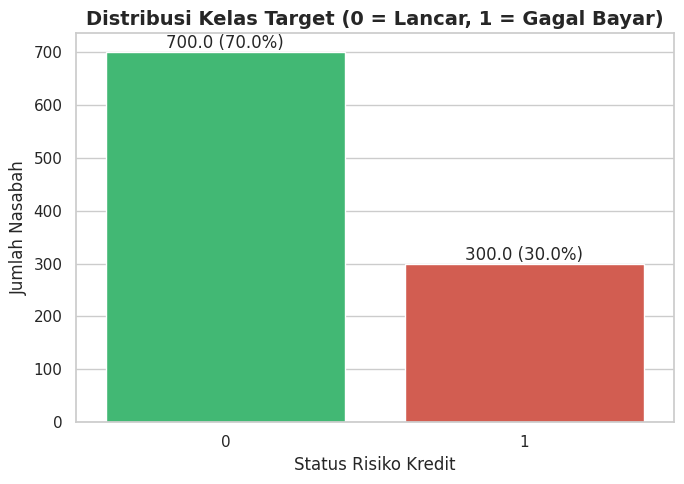

In [7]:
# Analisis Proporsi Target Klasifikasi (Class Imbalance Check)
target_counts = df['target_risk'].value_counts()
target_prop = df['target_risk'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(x='target_risk', data=df, palette=['#2ECC71', '#E74C3C'])
plt.title('Distribusi Kelas Target (0 = Lancar, 1 = Gagal Bayar)', fontsize=14, fontweight='bold')
plt.xlabel('Status Risiko Kredit')
plt.ylabel('Jumlah Nasabah')

# Menambahkan anotasi persentase
for i, p in enumerate(ax.patches):
    ax.annotate(f"{p.get_height()} ({target_prop[i]:.1f}%)", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

### 4.1 Analisis Spasial-Demografi dan Finansial (Bivariat)
Langkah selanjutnya adalah memvalidasi hipotesis bisnis: *Apakah besaran nominal kredit, durasi pinjaman, dan usia nasabah memiliki signifikansi statistik terhadap probabilitas gagal bayar?*

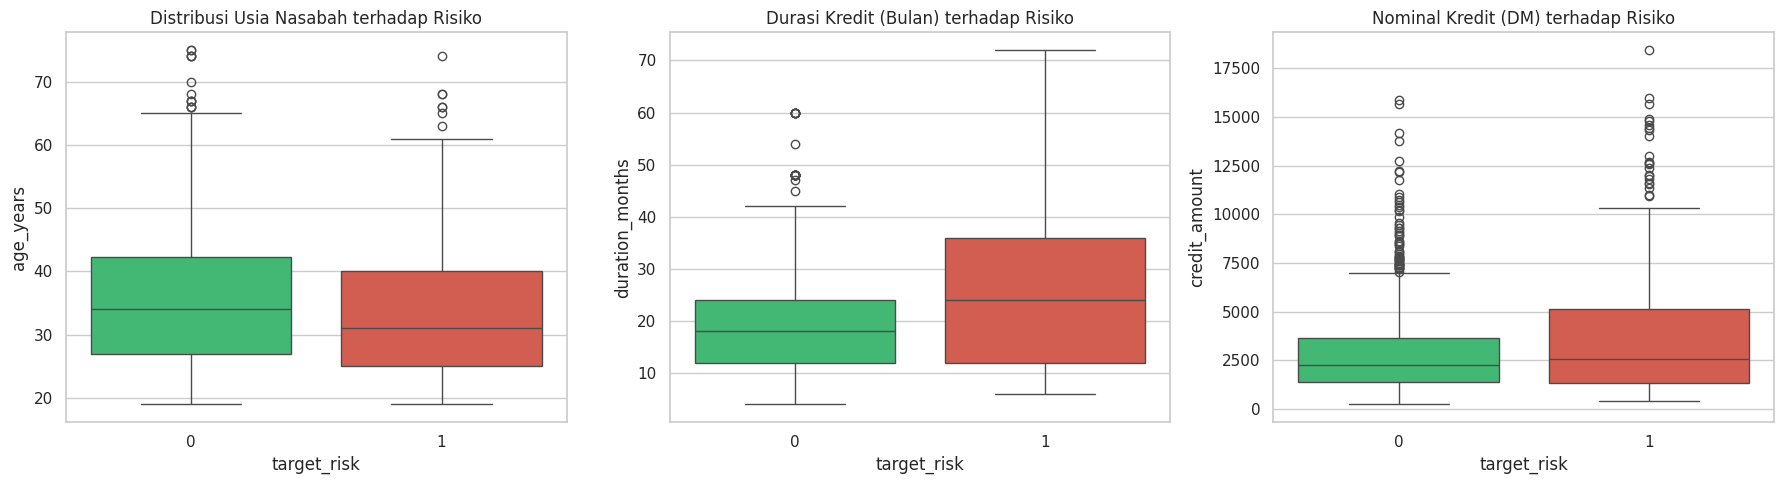

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribusi Umur vs Risiko
sns.boxplot(x='target_risk', y='age_years', data=df, ax=axes[0], palette=['#2ECC71', '#E74C3C'])
axes[0].set_title('Distribusi Usia Nasabah terhadap Risiko')

# 2. Distribusi Durasi Kredit vs Risiko
sns.boxplot(x='target_risk', y='duration_months', data=df, ax=axes[1], palette=['#2ECC71', '#E74C3C'])
axes[1].set_title('Durasi Kredit (Bulan) terhadap Risiko')

# 3. Distribusi Jumlah Kredit vs Risiko
sns.boxplot(x='target_risk', y='credit_amount', data=df, ax=axes[2], palette=['#2ECC71', '#E74C3C'])
axes[2].set_title('Nominal Kredit (DM) terhadap Risiko')

plt.tight_layout()
plt.show()

### 4.2 Laporan Hasil Telaah Data (Kesimpulan)
Berdasarkan hasil uji statistika deskriptif dan analisis bivariat, ditemukan formulasi hipotesis berikut yang akan dienkapsulasi pada *pipeline* pra-pemrosesan:

1. **Integritas Objek Data yang Absolut:** Himpunan matriks data yang terdiri dari 1.000 observasi dan 21 dimensi terbukti bersih dari elemen kosong secara eksplisit (`Null/NaN = 0`). Hal ini mengindikasikan integritas arsitektur ekstraksi data yang sangat baik, sehingga imputasi nilai tidak diperlukan pada tahap awal.
2. **Asimetri Kelas Target (Imbalanced Dataset):** Terdapat ketidakseimbangan kelas target dengan rasio distribusi 70:30 (Kelas 0 / *Good* : Kelas 1 / *Bad*). Asimetri ini mengamanatkan urgensi penerapan strategi *re-sampling*, seperti *Synthetic Minority Over-sampling Technique* (SMOTE), pada tahapan konstruksi agar fungsi kerugian (*loss function*) algoritma tidak terbias secara buta memprediksi kelas mayoritas.
3. **Korelasi Demografis & Finansial (Bivariat):** * **Demografi (Usia):** Terdapat indikasi bahwa nasabah dengan probabilitas *default* (1) memiliki tendensi distribusi usia yang lebih muda dibandingkan nasabah lancar.
    * **Beban Finansial:** Nasabah *default* secara empiris menunjukkan kecenderungan mengambil tenor pinjaman yang lebih panjang (`duration_months`) dengan eksposur nominal kredit yang masif (`credit_amount`). 
4. **Justifikasi Transformasi Skala:** Terdapat disparitas magnitudo yang ekstrem antara fitur `credit_amount` (rentang ribuan) dan fitur struktural lainnya seperti durasi atau umur (rentang puluhan). Kondisi ini memvalidasi urgensi standarisasi varians (*StandardScaler* atau *RobustScaler*) untuk memitigasi distorsi bobot pada algoritma *baseline* berjenis parametrik atau berbasis jarak (seperti *Logistic Regression* atau *SVM*), meskipun algoritma *Tree-based ensemble* secara matematis kebal terhadap anomali skala ini.

Tujuan teknis dan penelaahan data untuk Fase 1 telah tervalidasi. Proses dilanjutkan ke *Notebook 02: Validasi dan Konstruksi Data*.